# Randomized Smoothing

Everything below runs in **2D**, so every step is a picture. The algorithm is
identical in 3072 dimensions; only `f` changes.

The decision functions come from `randomized_smoothing.core` — the same code
that produced the CIFAR-10 results.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from randomized_smoothing.core import (
    ABSTAIN, certified_radius, certify_from_counts, clopper_pearson_lower,
)

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "figure.facecolor": "white"})


def f(points):
    '''Base classifier: (n,2) points -> (n,) labels in {0,1,2}. A black box.'''
    points = np.atleast_2d(np.asarray(points, dtype=float))
    x, y = points[:, 0], points[:, 1]
    boundary = 0.45 * np.sin(3.0 * y) + 0.25 * np.cos(5.0 * y + 1.0)
    labels = np.where(x > boundary, 1, 0)
    return np.where(y > 1.9, 2, labels).astype(int)


def plot_regions(ax, fn=f, lim=2.0, res=400):
    g = np.linspace(-lim, lim, res)
    xx, yy = np.meshgrid(g, g)
    zz = fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-.5, .5, 1.5, 2.5],
                colors=["#c6dbef", "#fdd0a2", "#c7e9c0"])
    ax.contour(xx, yy, zz, levels=[.5, 1.5], colors="#444", linewidths=.8)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    return ax


def g_vote(points, sigma, n, r):
    '''Monte Carlo estimate of the smoothed classifier g.'''
    points = np.atleast_2d(points)
    out = np.empty(len(points), dtype=int)
    for i, p in enumerate(points):
        out[i] = np.bincount(f(p + r.normal(0, sigma, (n, 2))), minlength=3).argmax()
    return out


def certify_2d(x, sigma, n0, n, alpha, r):
    '''CERTIFY on the toy - calls the same core function as the GPU run.'''
    sel = np.bincount(f(x + r.normal(0, sigma, (n0, 2))), minlength=3)
    est = np.bincount(f(x + r.normal(0, sigma, (n,  2))), minlength=3)
    return certify_from_counts(sel, est, sigma, alpha)


x0 = np.array([-0.55, 0.35])
print("ready")

ready


---
## 1. Classifier as a function

$f$ maps an input to a label. Ours takes a point $x=(x_1,x_2)$ and returns
0, 1 or 2. The boundary is deliberately **wiggly** — like a trained network's.

Randomized smoothing never looks inside $f$. It only calls it.

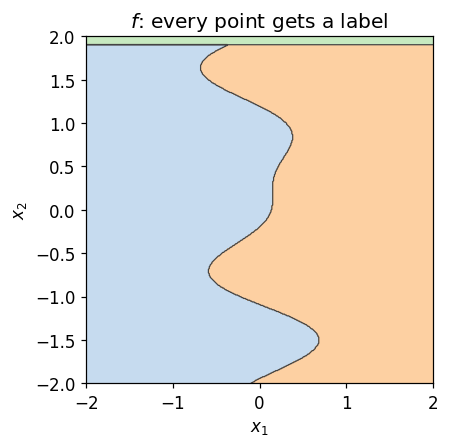

In [2]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
plot_regions(ax)
ax.set_title("$f$: every point gets a label")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.tight_layout(); plt.show()

---
## 2. Adversarial examples, and measuring them with $L_2$

An attacker adds a small vector $\delta$:  $x \rightarrow x + \delta$.
If the label flips while a human sees no change, that is an adversarial example.

We measure "small" with the $L_2$ norm — ordinary straight-line length:

$$\|\delta\|_2 = \sqrt{\delta_1^2 + \cdots + \delta_d^2}$$

So **$\|\delta\|_2 < r$ means "inside the circle of radius $r$"**. A certificate
of radius $r$ is a claim about everything in that circle.

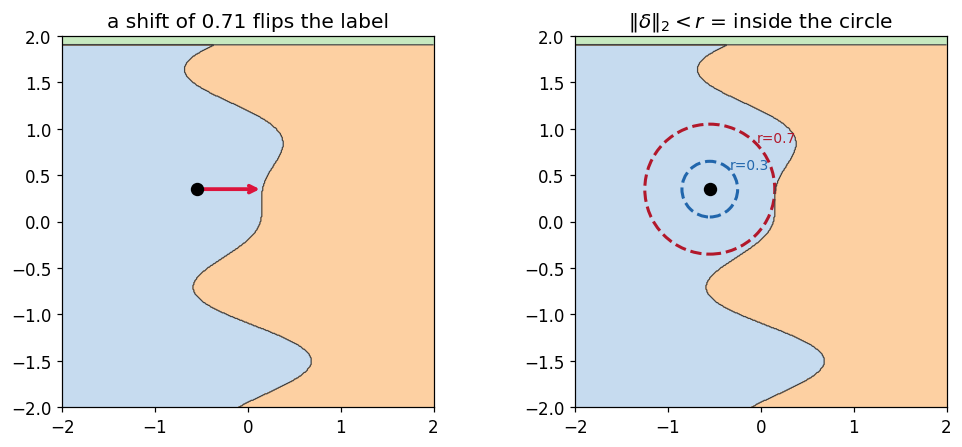

In [3]:
steps = np.linspace(0, 1.4, 60)
walk = x0 + np.c_[steps, np.zeros_like(steps)]
flip = steps[np.argmax(f(walk) != f(walk)[0])]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2))
plot_regions(axes[0])
axes[0].scatter(*x0, c="k", s=60, zorder=5)
axes[0].annotate("", xy=(x0[0] + flip, x0[1]), xytext=tuple(x0),
                 arrowprops=dict(arrowstyle="->", color="crimson", lw=2.5))
axes[0].set_title(f"a shift of {flip:.2f} flips the label")

plot_regions(axes[1])
for r_, c in [(0.3, "#2166ac"), (0.7, "#b2182b")]:
    axes[1].add_patch(plt.Circle(x0, r_, fill=False, color=c, lw=2, ls="--"))
    axes[1].text(x0[0] + r_ * .72, x0[1] + r_ * .72, f"r={r_}", color=c, fontsize=9)
axes[1].scatter(*x0, c="k", s=60, zorder=5)
axes[1].set_title(r"$\|\delta\|_2 < r$ = inside the circle")
plt.tight_layout(); plt.show()

---
## 3. replace $f$ by a vote over noise

Feed the classifier many noisy copies, $x + \varepsilon$ with
$\varepsilon \sim \mathcal{N}(0,\sigma^2 I)$, and take the majority:

$$g(x) \;=\; \arg\max_c \; \mathbb{P}\big(f(x+\varepsilon) = c\big)$$

- $g$ is **not** a network and is **never trained** — it wraps $f$.
- $\sigma$ is the method's only knob: how far the noise cloud spreads.
- $g$'s boundary is **smooth**. That smoothness is what we can prove things about.

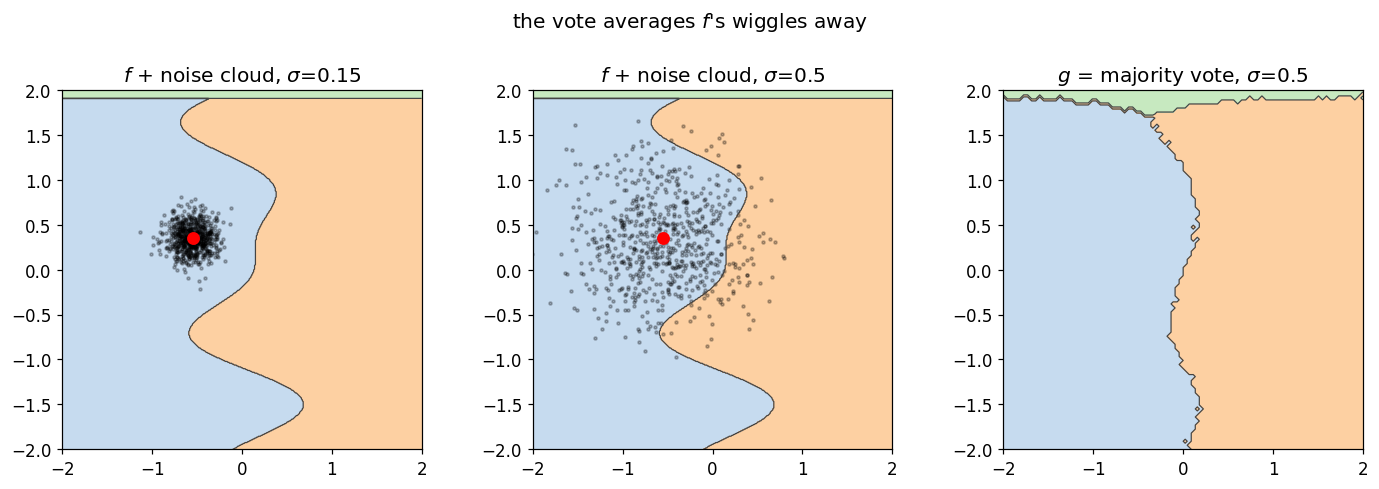

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, s in zip(axes[:2], [0.15, 0.50]):
    plot_regions(ax)
    cloud = x0 + rng.normal(0, s, size=(700, 2))
    ax.scatter(cloud[:, 0], cloud[:, 1], s=4, c="k", alpha=.25)
    ax.scatter(*x0, c="red", s=55, zorder=5)
    ax.set_title(f"$f$ + noise cloud, $\\sigma$={s}")

grid = np.linspace(-2, 2, 90)
xx, yy = np.meshgrid(grid, grid)
zz = g_vote(np.c_[xx.ravel(), yy.ravel()], 0.5, 1200,
            np.random.default_rng(1)).reshape(xx.shape)
axes[2].contourf(xx, yy, zz, levels=[-.5, .5, 1.5, 2.5],
                 colors=["#c6dbef", "#fdd0a2", "#c7e9c0"])
axes[2].contour(xx, yy, zz, levels=[.5, 1.5], colors="#444", linewidths=.8)
axes[2].set_aspect("equal"); axes[2].set_xlim(-2, 2); axes[2].set_ylim(-2, 2)
axes[2].set_title("$g$ = majority vote, $\\sigma$=0.5")
plt.suptitle("the vote averages $f$'s wiggles away", y=1.02)
plt.tight_layout(); plt.show()

---
## 4. $g$ cannot be computed exactly, so we need to sample

That probability is an integral over $\mathbb{R}^d$ against the Gaussian, of a
black box $f$. **No closed form.** So we estimate it by Monte Carlo: draw $n$
noisy copies, classify, count votes.

Consequence that drives the rest of the method: **every number we get about $g$
is an estimate with uncertainty.** Precision improves only as $1/\sqrt{n}$ —
4$\times$ the samples to halve the error.

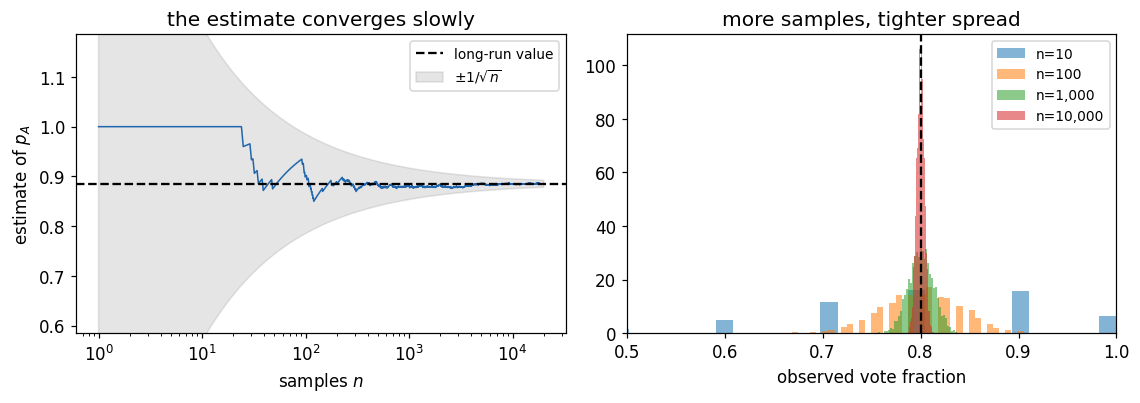

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
big = x0 + rng.normal(0, 0.5, size=(20000, 2))
hits = (f(big) == 0).astype(float)
run = np.cumsum(hits) / np.arange(1, len(hits) + 1)
nn = np.arange(1, len(hits) + 1)
axes[0].plot(nn, run, lw=1, color="#2166ac")
axes[0].axhline(hits.mean(), color="k", ls="--", lw=1.5, label="long-run value")
axes[0].fill_between(nn, hits.mean() - 1/np.sqrt(nn), hits.mean() + 1/np.sqrt(nn),
                     color="grey", alpha=.2, label=r"$\pm 1/\sqrt{n}$")
axes[0].set_xscale("log"); axes[0].set_ylim(hits.mean()-.3, hits.mean()+.3)
axes[0].set_xlabel("samples $n$"); axes[0].set_ylabel("estimate of $p_A$")
axes[0].legend(fontsize=9); axes[0].set_title("the estimate converges slowly")

for n_ in (10, 100, 1000, 10000):
    axes[1].hist(rng.binomial(n_, .8, 4000)/n_, bins=45, alpha=.55,
                 density=True, label=f"n={n_:,}")
axes[1].axvline(.8, color="k", ls="--", lw=1.5)
axes[1].set_xlim(.5, 1); axes[1].set_xlabel("observed vote fraction")
axes[1].legend(fontsize=9); axes[1].set_title("more samples, tighter spread")
plt.tight_layout(); plt.show()

---
## 5. From votes to a probability we can defend

$p_A$ = the **true** probability the noisy copies land on the winning class.
We never see it; we see e.g. 920 of 1000 votes.

Using 0.92 would break the guarantee — an observed fraction exceeds the truth
about half the time, and overestimating $p_A$ gives a radius that is too large,
i.e. false.

So we use a **lower confidence bound** $\underline{p_A}$:

$$\mathbb{P}\big(\underline{p_A} \le p_A\big) \ge 1-\alpha$$

$\alpha$ is a parameter **we choose** — the failure rate we tolerate. The paper
uses $\alpha = 0.001$, i.e. 99.9% confidence. Smaller $\alpha$ = stronger
evidence demanded = lower bound = **smaller radius**. Confidence costs radius.

observed 920/1000 = 0.92

   alpha   confidence   pA_lower   given up
--------------------------------------------
    0.05      95.00%     0.9044     0.0156
    0.01      99.00%     0.8978     0.0222
   0.001      99.90%     0.8901     0.0299
  0.0001      99.99%     0.8835     0.0365


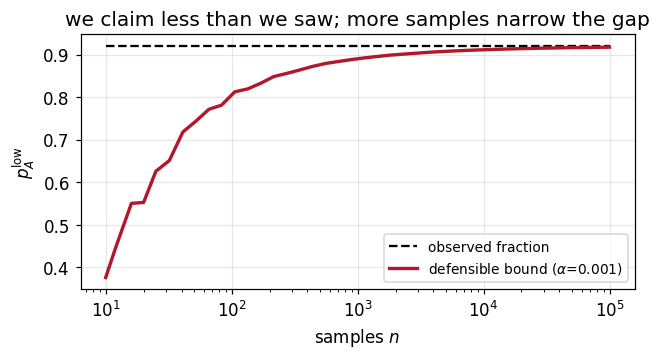

In [6]:
obs = 0.92
print(f"observed 920/1000 = {obs}\n")
print(f"{'alpha':>8} {'confidence':>12} {'pA_lower':>10} {'given up':>10}")
print("-" * 44)
for a in (0.05, 0.01, 0.001, 0.0001):
    lo = clopper_pearson_lower(920, 1000, a)
    print(f"{a:>8} {1-a:>11.2%} {lo:>10.4f} {obs-lo:>10.4f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ns = np.unique(np.logspace(1, 5, 40).astype(int))
ax.plot(ns, [obs]*len(ns), "k--", lw=1.5, label="observed fraction")
ax.plot(ns, [clopper_pearson_lower(int(round(obs*n)), n, 0.001) for n in ns],
        lw=2.2, color="#b2182b", label=r"defensible bound ($\alpha$=0.001)")
ax.set_xscale("log"); ax.set_xlabel("samples $n$")
ax.set_ylabel(r"$p_A^{\mathrm{low}}$"); ax.legend(fontsize=9); ax.grid(alpha=.3)
ax.set_title("we claim less than we saw; more samples narrow the gap")
plt.tight_layout(); plt.show()

---
## 6. $\Phi^{-1}$ turns confidence into distance

$\Phi(z)$ = area under the standard bell curve left of $z$ = probability a draw
lands below $z$. $\Phi^{-1}$ inverts it: **probability in, distance out**.

$$\Phi^{-1}(0.5)=0,\qquad \Phi^{-1}(0.9)\approx1.28,\qquad \Phi^{-1}(0.99)\approx2.33$$

$\Phi^{-1}$ is the inverse *function*, not $1/\Phi$. It grows without bound as
$p \to 1$: more certainty buys more distance.

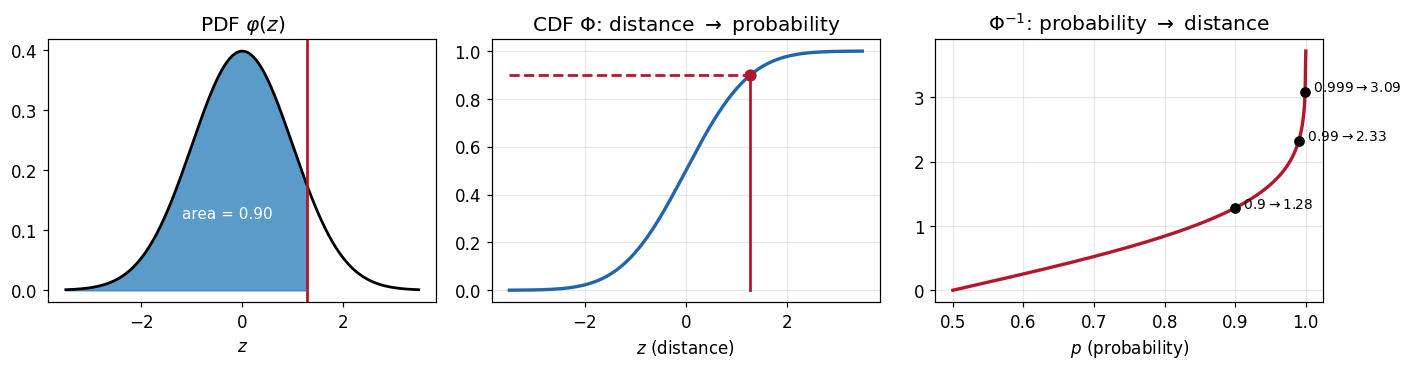

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
z = np.linspace(-3.5, 3.5, 500); z0 = 1.28

axes[0].plot(z, norm.pdf(z), "k", lw=1.8)
m = z <= z0
axes[0].fill_between(z[m], norm.pdf(z[m]), color="#3182bd", alpha=.8)
axes[0].axvline(z0, color="#b2182b", lw=1.8)
axes[0].text(-1.2, .12, "area = 0.90", color="white", fontsize=10)
axes[0].set_xlabel("$z$"); axes[0].set_title(r"PDF $\varphi(z)$")

axes[1].plot(z, norm.cdf(z), lw=2.2, color="#2166ac")
axes[1].plot([z0, z0], [0, norm.cdf(z0)], color="#b2182b", lw=1.8)
axes[1].plot([-3.5, z0], [norm.cdf(z0)]*2, color="#b2182b", lw=1.8, ls="--")
axes[1].plot([z0], [norm.cdf(z0)], "o", color="#b2182b", ms=7)
axes[1].set_xlabel("$z$ (distance)"); axes[1].grid(alpha=.3)
axes[1].set_title(r"CDF $\Phi$: distance $\to$ probability")

p = np.linspace(0.5, 0.9999, 500)
axes[2].plot(p, norm.ppf(p), lw=2.2, color="#b2182b")
for pv in (0.9, 0.99, 0.999):
    axes[2].plot([pv], [norm.ppf(pv)], "ko", ms=6)
    axes[2].annotate(f"  {pv}$\\to${norm.ppf(pv):.2f}", (pv, norm.ppf(pv)), fontsize=9)
axes[2].set_xlabel("$p$ (probability)"); axes[2].grid(alpha=.3)
axes[2].set_title(r"$\Phi^{-1}$: probability $\to$ distance")
plt.tight_layout(); plt.show()

---
## 7. The certificate

$$\boxed{\;R \;=\; \sigma \cdot \Phi^{-1}\big(\underline{p_A}\big)\;}$$

$$\|\delta\|_2 < R \quad\Longrightarrow\quad g(x+\delta) = g(x)$$

Read it as a product: **$\sigma$ sets the unit of distance**, and
**$\Phi^{-1}(\underline{p_A})$ says how many units our confidence bought.**

This is the binary case of the paper's Theorem 1,
$R=\frac{\sigma}{2}\big(\Phi^{-1}(p_A)-\Phi^{-1}(p_B)\big)$, with the worst case
$p_B \le 1-p_A$ substituted in — one quantity to estimate instead of two.

Note $\Phi^{-1}(0.5)=0$: a coin-flip vote certifies nothing.

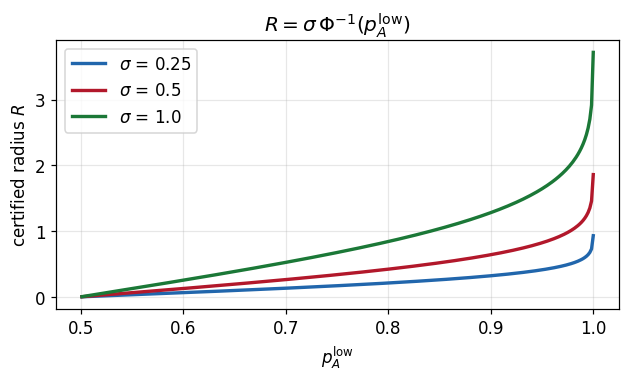

sigma=0.25  pA_low=0.60  ->  R = 0.063
sigma=0.25  pA_low=0.90  ->  R = 0.320
sigma=0.25  pA_low=0.99  ->  R = 0.582
sigma=1.00  pA_low=0.60  ->  R = 0.253
sigma=1.00  pA_low=0.90  ->  R = 1.282
sigma=1.00  pA_low=0.99  ->  R = 2.326


In [8]:
fig, ax = plt.subplots(figsize=(6, 3.6))
pl = np.linspace(0.501, 0.9999, 300)
for s, c in [(0.25, "#2166ac"), (0.50, "#b2182b"), (1.00, "#1b7837")]:
    ax.plot(pl, [certified_radius(s, p) for p in pl], lw=2.2, color=c,
            label=f"$\\sigma$ = {s}")
ax.set_xlabel(r"$p_A^{\mathrm{low}}$"); ax.set_ylabel("certified radius $R$")
ax.set_title(r"$R = \sigma\,\Phi^{-1}(p_A^{\mathrm{low}})$")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

for s in (0.25, 1.00):
    for p in (0.60, 0.90, 0.99):
        print(f"sigma={s:.2f}  pA_low={p:.2f}  ->  R = {certified_radius(s, p):.3f}")

---
## 8. CERTIFY draws **two** samples — and may abstain

| sample | size | job | afterwards |
|---|---|---|---|
| first | $n_0 = 100$ | **select** a candidate class $A$ | discarded |
| second | $n = 100{,}000$ | **measure** that already-fixed class | gives $\underline{p_A}$ |

**Why two.** You cannot pick the winner and score it with the same votes. If ten
classes are genuinely tied, one of them tops the sample by luck; scoring that
class on the same votes measures *the maximum of ten noisy measurements*, not a
probability. It is biased upward, and Clopper–Pearson assumes the class was
fixed **before** the sample — break that and the guarantee is void.

So $n_0$ may only *point*, never *measure*. The sizes differ 1000$\times$
because choosing a winner is cheap; proving a probability is near 1 is expensive.

**ABSTAIN.** If $\underline{p_A} \le 0.5$ we cannot prove class $A$ even holds a
majority, so there is no ball to certify and CERTIFY returns ABSTAIN. That is
correct behaviour, not failure — the alternative is issuing false certificates.
In the results, abstentions count as **errors**, so the method pays for its own
caution.

In [9]:
print(f"{'votes A vs B':>16} | {'pA_low':>8} | {'CERTIFY':>18}")
print("-" * 50)
for a_ in (505, 550, 700, 900, 990, 1000):
    counts = np.array([a_, 1000 - a_])
    r = certify_from_counts(np.array([1, 0]), counts, sigma=0.5, alpha=0.001)
    out = "ABSTAIN" if r.abstained else f"class 0,  R = {r.radius:.3f}"
    print(f"{a_:>7} vs {1000-a_:<5} | {r.lower_probability:>8.4f} | {out:>18}")

    votes A vs B |   pA_low |            CERTIFY
--------------------------------------------------
    505 vs 495   |   0.4557 |            ABSTAIN
    550 vs 450   |   0.5007 | class 0,  R = 0.001
    700 vs 300   |   0.6535 | class 0,  R = 0.197
    900 vs 100   |   0.8675 | class 0,  R = 0.557
    990 vs 10    |   0.9760 | class 0,  R = 0.989
   1000 vs 0     |   0.9931 | class 0,  R = 1.232


---
## 9. The algorithm, end to end

```
CERTIFY(f, sigma, x, n0, n, alpha):
    counts0 <- classify n0 noisy copies of x            # SELECT
    A       <- argmax(counts0)                          # a guess; then discard
    counts  <- classify n FRESH noisy copies            # MEASURE
    pA_low  <- ClopperPearsonLower(counts[A], n, alpha) # be pessimistic
    if pA_low <= 0.5:  return ABSTAIN
    else:              return A, sigma * Phi^-1(pA_low)
```

Each circle below is a region $g$ provably cannot leave; $\times$ marks an
abstention. Note the circles stop short of the boundary — that is the guarantee
being conservative.

**One limitation to keep in view:** the certificate says the prediction *will
not change*. It does **not** say it is *correct*. A model can be confidently,
robustly, certifiably wrong — which is why results are reported as *certified
accuracy* (correct **and** certified).

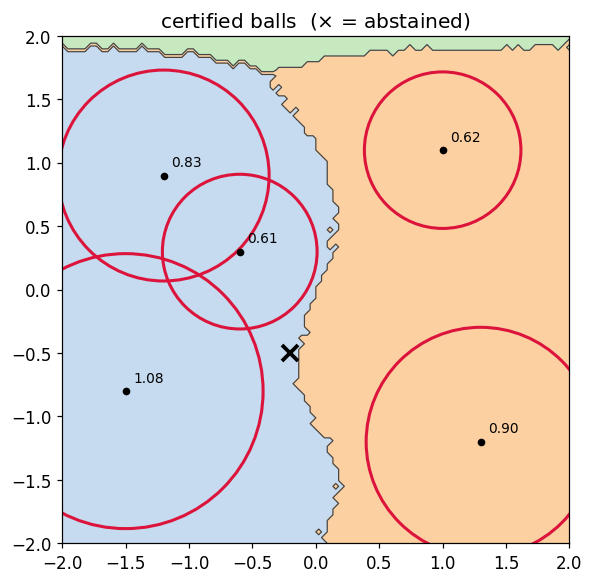

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
grid = np.linspace(-2, 2, 90)
xx, yy = np.meshgrid(grid, grid)
zz = g_vote(np.c_[xx.ravel(), yy.ravel()], 0.5, 1200,
            np.random.default_rng(1)).reshape(xx.shape)
ax.contourf(xx, yy, zz, levels=[-.5, .5, 1.5, 2.5],
            colors=["#c6dbef", "#fdd0a2", "#c7e9c0"])
ax.contour(xx, yy, zz, levels=[.5, 1.5], colors="#444", linewidths=.8)

r = np.random.default_rng(11)
for pt in ([-1.5, -0.8], [-1.2, 0.9], [-0.6, 0.3], [-0.2, -0.5], [1.3, -1.2], [1.0, 1.1]):
    res = certify_2d(np.array(pt), 0.5, 100, 10000, 0.001, r)
    if res.abstained:
        ax.plot(*pt, "kx", ms=11, mew=2.5)
    else:
        ax.add_patch(plt.Circle(pt, res.radius, fill=False, color="crimson", lw=2))
        ax.plot(*pt, "ko", ms=4)
        ax.annotate(f"{res.radius:.2f}", pt, textcoords="offset points",
                    xytext=(5, 6), fontsize=9)
ax.set_aspect("equal"); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_title("certified balls  ($\\times$ = abstained)")
plt.tight_layout(); plt.show()

---
## 10. The same code, on real images

Nothing in the algorithm changes. Only $f$ (a ResNet-110) and $d$
($2 \rightarrow 3072$).

One number worth carrying over: a Gaussian noise vector has typical length
$\mathbb{E}\|\varepsilon\|_2 \approx \sigma\sqrt{d}$, so at $\sigma=0.25$ on
CIFAR-10 that is $0.25\sqrt{3072} \approx 13.9$ — far larger than the bare
$\sigma$ suggests, and why $\sigma$ values cannot be moved between datasets.

Below is what the base classifier actually sees. At $\sigma = 1.00$ you can
barely identify these — and the network must vote correctly on 100,000 of them.
**This is why $f$ must be trained on noisy images.**

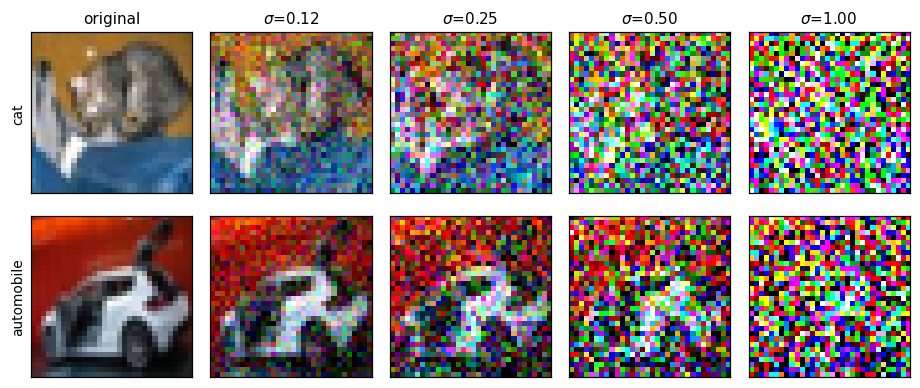

d = 3072;  sigma=0.25 noise has typical length 13.9


In [11]:
import pickle, pathlib

def load_cifar10_test(root="../data/cifar-10-batches-py"):
    root = pathlib.Path(root)
    with open(root / "test_batch", "rb") as fh:
        d = pickle.load(fh, encoding="bytes")
    with open(root / "batches.meta", "rb") as fh:
        names = [n.decode() for n in pickle.load(fh, encoding="bytes")[b"label_names"]]
    images = d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1) / 255.0
    return images, np.array(d[b"labels"]), names

try:
    images, labels, names = load_cifar10_test()
    r = np.random.default_rng(0)
    picks, sigmas = [0, 6], [0.0, 0.12, 0.25, 0.50, 1.00]
    fig, axes = plt.subplots(len(picks), len(sigmas),
                             figsize=(1.7*len(sigmas), 1.9*len(picks)))
    for row, i in enumerate(picks):
        for col, s in enumerate(sigmas):
            ax = axes[row, col]
            ax.imshow(np.clip(images[i] + r.normal(0, s, images[i].shape), 0, 1))
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title("original" if s == 0 else f"$\\sigma$={s:.2f}", fontsize=10)
            if col == 0:
                ax.set_ylabel(names[labels[i]], fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"d = {images[0].size};  sigma=0.25 noise has typical length "
          f"{0.25*np.sqrt(images[0].size):.1f}")
except FileNotFoundError:
    print("CIFAR-10 not found under ../data/cifar-10-batches-py")